In [1]:
import pandas as pd

In [2]:
seasonal_files = {
	'jan': ['jan-24.csv', 'jan-25.csv', 'jan-26.csv'],
	'apr': ['apr-24.csv', 'apr-25.csv', 'apr-26.csv'],
	'jul': ['jul-23.csv', 'jul-24.csv', 'jul-25.csv'],
	'oct': ['oct-23.csv', 'oct-24.csv', 'oct-25.csv']
}

In [ ]:
all_months_stats = []

for month, filenames in seasonal_files.items():
    month_data_list = []
    for file in filenames:
        try:
            df = pd.read_csv(file, usecols=['OPR_HR', 'LMP_TYPE', 'MW'])
            df = df[df['LMP_TYPE'] == 'LMP']
            month_data_list.append(df[['OPR_HR', 'MW']])
        except FileNotFoundError:
            continue

    if month_data_list:
        combined = pd.concat(month_data_list)

        # Aggregate by both mean and variance
        stats = combined.groupby('OPR_HR')['MW'].agg(['mean', 'std'])

        # Rename columns to include the month name for clarity
        stats.columns = [f'{month}_mean', f'{month}_std']
        all_months_stats.append(stats)

# Join all monthly dataframes along the OPR_HR index
final_df_stats = pd.concat(all_months_stats, axis=1).sort_index()

# Export the detailed statistical dataframe
final_df_stats.to_csv('seasonal_stats.csv')

print(final_df_stats.head())

         jan_mean    jan_std   apr_mean   apr_std   jul_mean    jul_std  \
OPR_HR                                                                    
1       54.256519  31.765096  31.362794  7.166950  47.197820  10.761032   
2       52.624304  30.294400  30.278311  6.635775  44.577757   9.321642   
3       52.005504  30.195012  29.431398  6.280076  42.807445   8.225738   
4       51.757236  30.116896  29.176418  6.437772  42.132127   7.979954   
5       52.895713  30.534552  30.013085  6.617608  42.671266   8.025942   

         oct_mean   oct_std  
OPR_HR                       
1       48.731158  9.998035  
2       46.562532  8.973037  
3       45.514254  8.460294  
4       45.069307  8.327658  
5       45.507683  8.475660  


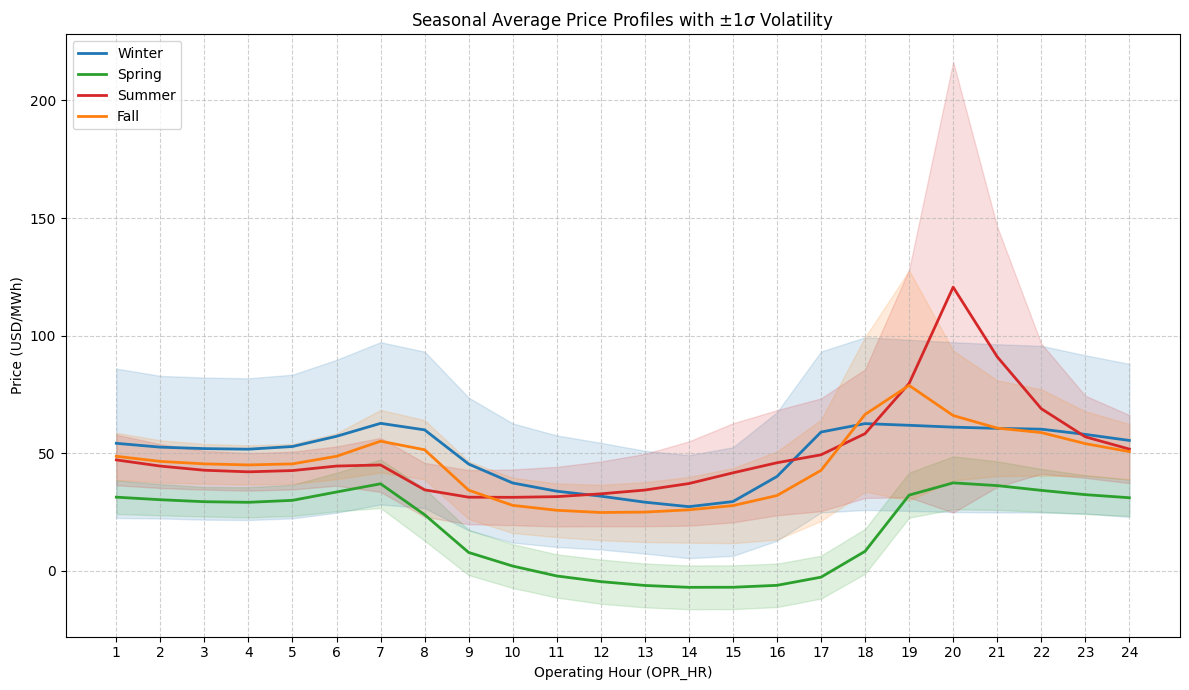

In [ ]:
import matplotlib.pyplot as plt

# Define color palette
colors = {'jan': '#1f77b4', 'apr': '#2ca02c', 'jul': '#d62728', 'oct': '#ff7f0e'}
labels = {'jan': 'Winter', 'apr': 'Spring', 'jul': 'Summer', 'oct': 'Autumn'}

plt.figure(figsize=(12, 7))

for month in ['jan', 'apr', 'jul', 'oct']:
    mean_col = f'{month}_mean'
    std_col = f'{month}_std'

    # Plot the mean line
    plt.plot(final_df_stats.index, final_df_stats[mean_col],
             label=labels[month], color=colors[month], linewidth=2)

    # Add shaded +/- 1 sigma region
    plt.fill_between(final_df_stats.index,
                     final_df_stats[mean_col] - final_df_stats[std_col],
                     final_df_stats[mean_col] + final_df_stats[std_col],
                     color=colors[month], alpha=0.15, label='_nolegend_')

# Formatting
plt.xlabel('Operating Hour (OPR_HR)')
plt.ylabel("Price (USD/MWh)")
plt.title(r'Seasonal Average Price Profiles with $\pm 1\sigma$ Volatility')
plt.xticks(range(1, 25))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('seasonal_price_volatility.png')